In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Same chart style as EDA notebook
plt.rcParams.update({
    'figure.facecolor':  '#0F1117',
    'axes.facecolor':    '#1A1D27',
    'axes.edgecolor':    '#2E3250',
    'axes.labelcolor':   '#E0E0E0',
    'axes.titlesize':    14,
    'axes.titleweight':  'bold',
    'axes.titlecolor':   '#FFFFFF',
    'xtick.color':       '#B0B0B0',
    'ytick.color':       '#B0B0B0',
    'text.color':        '#E0E0E0',
    'grid.color':        '#2E3250',
    'grid.linestyle':    '--',
    'grid.alpha':        0.5,
    'font.family':       'DejaVu Sans',
    'figure.dpi':        150,
})

COLORS = {
    'primary':   '#4F8EF7',
    'secondary': '#F7C948',
    'accent':    '#F75A5A',
    'green':     '#4CAF82',
    'purple':    '#9B59F7',
    'text':      '#FFFFFF',
    'subtext':   '#B0B0B0',
}

CHARTS_DIR = '../outputs/charts/'
import os
os.makedirs(CHARTS_DIR, exist_ok=True)

def save_chart(filename):
    plt.savefig(f"{CHARTS_DIR}{filename}",
                bbox_inches='tight',
                facecolor=plt.rcParams['figure.facecolor'],
                dpi=150)
    plt.show()
    print(f"✅ Saved: {CHARTS_DIR}{filename}")

# Load processed data
df_tech   = pd.read_csv('../data/processed/tech_jobs_cleaned.csv')
df_skills = pd.read_csv('../data/processed/skills_exploded.csv')
df_salary = df_tech[df_tech['salary_lpa'] > 0].copy()

print(f"df_tech:   {df_tech.shape}")
print(f"df_skills: {df_skills.shape}")
print(f"df_salary: {df_salary.shape}")
print(f"\n✅ Phase 7 setup complete")

df_tech:   (32438, 27)
df_skills: (241109, 15)
df_salary: (6376, 27)

✅ Phase 7 setup complete


In [9]:
# ── Analysis 7.1: Does more skills = higher salary? ──────────

# Count skills per job from the skills table
skill_counts_per_job = (df_skills.groupby('jobId')['skill']
                        .count()
                        .reset_index()
                        .rename(columns={'skill': 'skill_count'}))

# Merge with salary data
salary_skills = (df_salary[['jobId', 'salary_lpa']]
                 .merge(skill_counts_per_job, on='jobId', how='inner'))

print(f"Rows for correlation analysis: {len(salary_skills):,}")
print(f"\nSkill count distribution:")
print(salary_skills['skill_count'].describe().round(2))

# Pearson correlation
r, p_value = stats.pearsonr(salary_skills['skill_count'],
                             salary_skills['salary_lpa'])

print(f"\nPearson Correlation (r): {r:.4f}")
print(f"P-value:                  {p_value:.6f}")
print(f"Statistically significant: {p_value < 0.05}")

# Interpret effect size
if abs(r) < 0.1:    strength = "negligible"
elif abs(r) < 0.3:  strength = "weak"
elif abs(r) < 0.5:  strength = "moderate"
else:               strength = "strong"
print(f"Effect size:              {strength} ({abs(r):.3f})")

Rows for correlation analysis: 6,376

Skill count distribution:
count    6376.00
mean        7.43
std         1.06
min         1.00
25%         7.00
50%         8.00
75%         8.00
max         8.00
Name: skill_count, dtype: float64

Pearson Correlation (r): 0.0201
P-value:                  0.108766
Statistically significant: False
Effect size:              negligible (0.020)


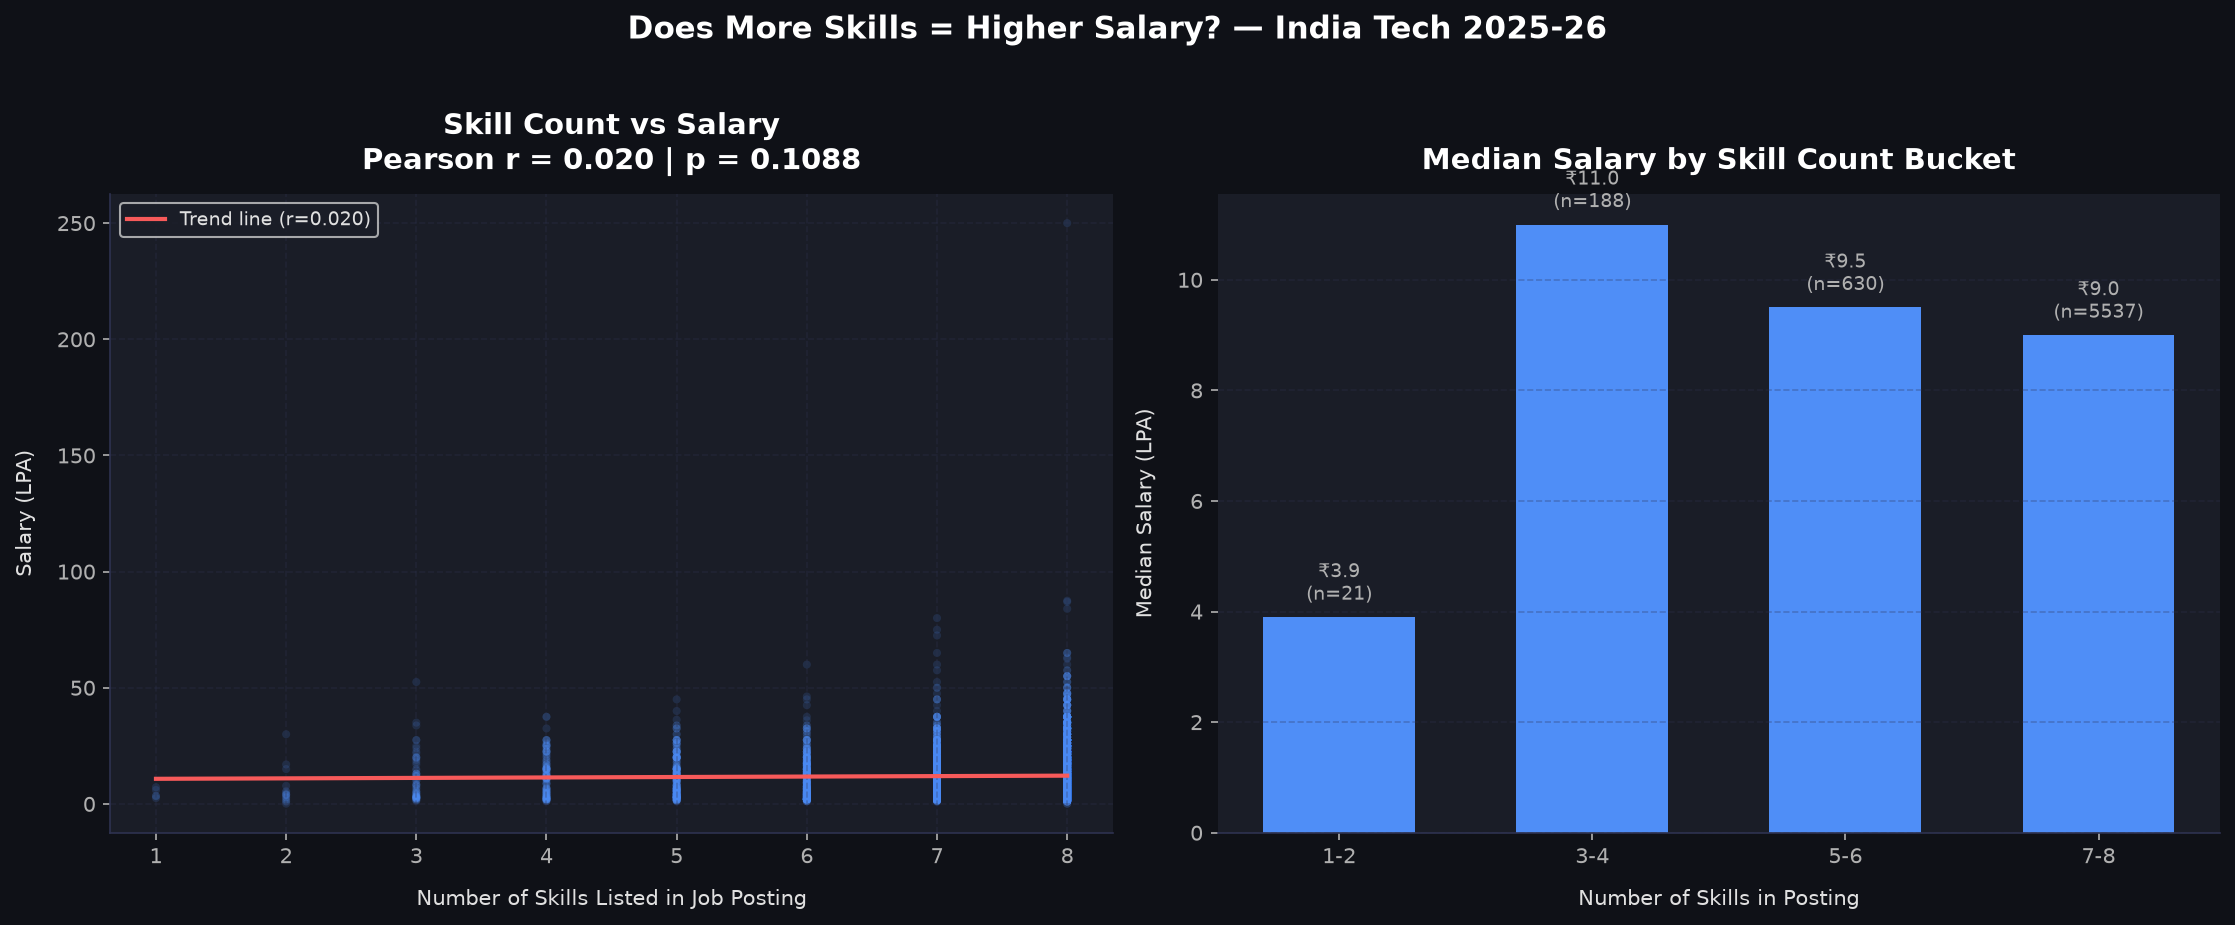

✅ Saved: ../outputs/charts/F1_skill_count_salary_correlation.png


In [10]:
# Visualize the relationship
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Left: scatter with regression line
ax1 = axes[0]
ax1.scatter(salary_skills['skill_count'],
            salary_skills['salary_lpa'],
            alpha=0.15, color=COLORS['primary'],
            s=15, edgecolors='none')

# Regression line
m, b = np.polyfit(salary_skills['skill_count'],
                  salary_skills['salary_lpa'], 1)
x_line = np.linspace(salary_skills['skill_count'].min(),
                     salary_skills['skill_count'].max(), 100)
ax1.plot(x_line, m * x_line + b,
         color=COLORS['accent'], linewidth=2,
         label=f'Trend line (r={r:.3f})')

ax1.set_xlabel('Number of Skills Listed in Job Posting', labelpad=10)
ax1.set_ylabel('Salary (LPA)', labelpad=10)
ax1.set_title(f'Skill Count vs Salary\nPearson r = {r:.3f} | p = {p_value:.4f}',
              pad=12)
ax1.legend(fontsize=9)
ax1.grid(alpha=0.3)
ax1.spines[['top', 'right']].set_visible(False)

# Right: median salary by skill count bucket
ax2 = axes[1]
salary_skills['skill_bucket'] = pd.cut(salary_skills['skill_count'],
                                        bins=[0,2,4,6,8,20],
                                        labels=['1-2','3-4','5-6','7-8','8+'])
bucket_stats = (salary_skills.groupby('skill_bucket', observed=True)['salary_lpa']
                .agg(['median','count'])
                .reset_index())

bars = ax2.bar(bucket_stats['skill_bucket'].astype(str),
               bucket_stats['median'],
               color=COLORS['primary'],
               edgecolor='none', width=0.6)

for bar, row in zip(bars, bucket_stats.itertuples()):
    ax2.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.2,
             f'₹{row.median:.1f}\n(n={row.count})',
             ha='center', va='bottom', fontsize=9,
             color=COLORS['subtext'])

ax2.set_xlabel('Number of Skills in Posting', labelpad=10)
ax2.set_ylabel('Median Salary (LPA)', labelpad=10)
ax2.set_title('Median Salary by Skill Count Bucket',  pad=12)
ax2.grid(axis='y', alpha=0.3)
ax2.spines[['top', 'right', 'left']].set_visible(False)

plt.suptitle('Does More Skills = Higher Salary? — India Tech 2025-26',
             fontsize=15, fontweight='bold', color='white', y=1.02)
plt.tight_layout()
save_chart('F1_skill_count_salary_correlation.png')

In [11]:
# ── Analysis 7.2: Is Hyderabad salary significantly > Bengaluru? ──

hyd_salary = df_salary[df_salary['city_tier_group'] == 'Hyderabad']['salary_lpa']
blr_salary = df_salary[df_salary['city_tier_group'] == 'Bengaluru']['salary_lpa']
pune_salary = df_salary[df_salary['city_tier_group'] == 'Pune']['salary_lpa']

print("CITY SALARY COMPARISON")
print("=" * 50)
print(f"Hyderabad: n={len(hyd_salary)}, "
      f"median=₹{hyd_salary.median():.2f} LPA, "
      f"mean=₹{hyd_salary.mean():.2f} LPA")
print(f"Bengaluru: n={len(blr_salary)}, "
      f"median=₹{blr_salary.median():.2f} LPA, "
      f"mean=₹{blr_salary.mean():.2f} LPA")
print(f"Pune:      n={len(pune_salary)}, "
      f"median=₹{pune_salary.median():.2f} LPA, "
      f"mean=₹{pune_salary.mean():.2f} LPA")

# Mann-Whitney U: Hyderabad vs Bengaluru
u_stat, p_hyd_blr = stats.mannwhitneyu(hyd_salary, blr_salary,
                                         alternative='two-sided')
print(f"\nMann-Whitney U Test: Hyderabad vs Bengaluru")
print(f"U-statistic: {u_stat:.0f}")
print(f"P-value:     {p_hyd_blr:.4f}")
print(f"Significant: {p_hyd_blr < 0.05}")
if p_hyd_blr >= 0.05:
    print("→ The salary difference is NOT statistically significant")
    print("  (Hyderabad and Bengaluru are statistically equivalent)")
else:
    print("→ The salary difference IS statistically significant")

# Mann-Whitney U: Bengaluru vs Pune
u_stat2, p_blr_pune = stats.mannwhitneyu(blr_salary, pune_salary,
                                           alternative='greater')
print(f"\nMann-Whitney U Test: Bengaluru > Pune?")
print(f"P-value: {p_blr_pune:.6f}")
print(f"Significant: {p_blr_pune < 0.05}")

CITY SALARY COMPARISON
Hyderabad: n=949, median=₹13.50 LPA, mean=₹14.89 LPA
Bengaluru: n=839, median=₹13.25 LPA, mean=₹15.83 LPA
Pune:      n=842, median=₹7.00 LPA, mean=₹11.06 LPA

Mann-Whitney U Test: Hyderabad vs Bengaluru
U-statistic: 390314
P-value:     0.4745
Significant: False
→ The salary difference is NOT statistically significant
  (Hyderabad and Bengaluru are statistically equivalent)

Mann-Whitney U Test: Bengaluru > Pune?
P-value: 0.000000
Significant: True


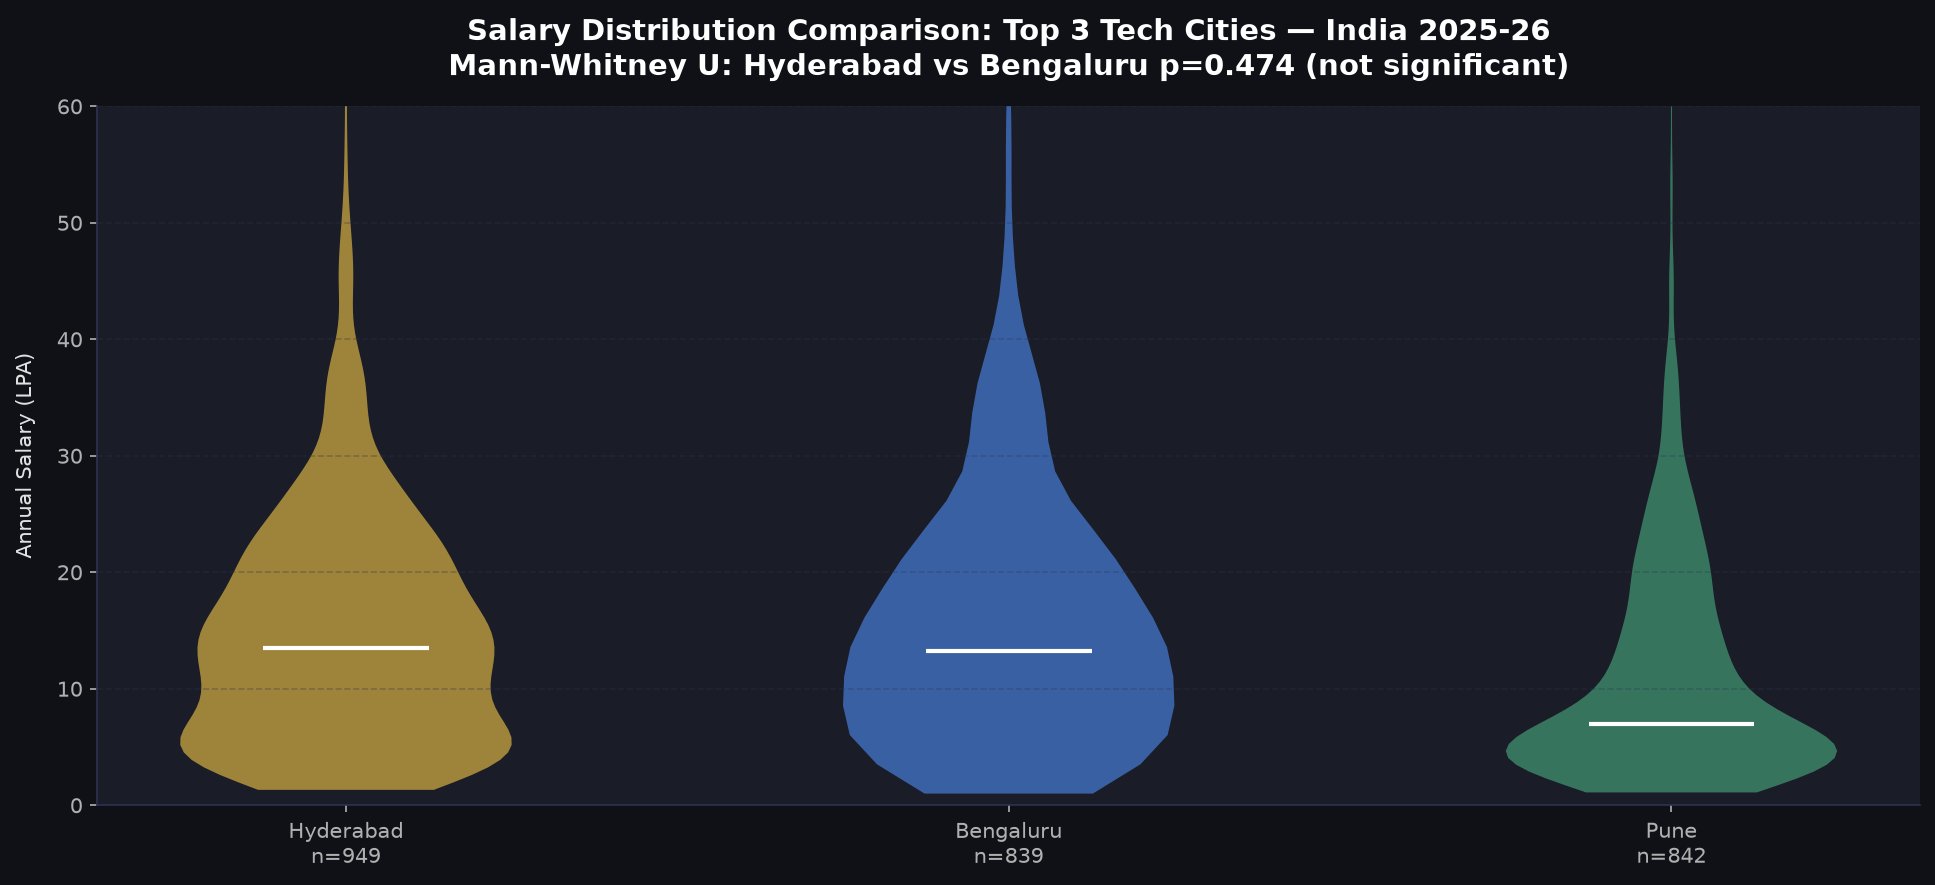

✅ Saved: ../outputs/charts/F2_city_salary_significance.png


In [12]:
# Visualize the comparison
fig, ax = plt.subplots(figsize=(13, 6))

city_data = {
    'Hyderabad': hyd_salary,
    'Bengaluru': blr_salary,
    'Pune': pune_salary
}

# Violin + box overlay
parts = ax.violinplot([hyd_salary, blr_salary, pune_salary],
                       positions=[1, 2, 3],
                       showmedians=True,
                       showextrema=False)

colors_violin = [COLORS['secondary'], COLORS['primary'], COLORS['green']]
for pc, color in zip(parts['bodies'], colors_violin):
    pc.set_facecolor(color)
    pc.set_alpha(0.6)
parts['cmedians'].set_color('white')
parts['cmedians'].set_linewidth(2)

ax.set_xticks([1, 2, 3])
ax.set_xticklabels([f'Hyderabad\nn={len(hyd_salary)}',
                    f'Bengaluru\nn={len(blr_salary)}',
                    f'Pune\nn={len(pune_salary)}'])
ax.set_ylabel('Annual Salary (LPA)', labelpad=10)
ax.set_title('Salary Distribution Comparison: Top 3 Tech Cities — India 2025-26\n'
             f'Mann-Whitney U: Hyderabad vs Bengaluru p={p_hyd_blr:.3f} '
             f'{"(not significant)" if p_hyd_blr >= 0.05 else "(significant)"}',
             pad=15)
ax.set_ylim(0, 60)
ax.grid(axis='y', alpha=0.3)
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
save_chart('F2_city_salary_significance.png')

Spearman Correlation (ρ): 0.7427
P-value:                  0.000000
Significant:              True

Median salary by experience year:
 exp_years  median  count
       0.0    2.75    501
       1.0    3.25    642
       2.0    4.50    715
       3.0    6.00    834
       4.0    9.50    725
       5.0   13.00   1051
       6.0   18.75    640
       7.0   17.50    341
       8.0   20.00    365
       9.0   21.00     77
      10.0   22.50    284
      11.0   25.00     13
      12.0   25.00    102
      13.0   30.00     15
      14.0   21.50      7
      15.0   35.00     41


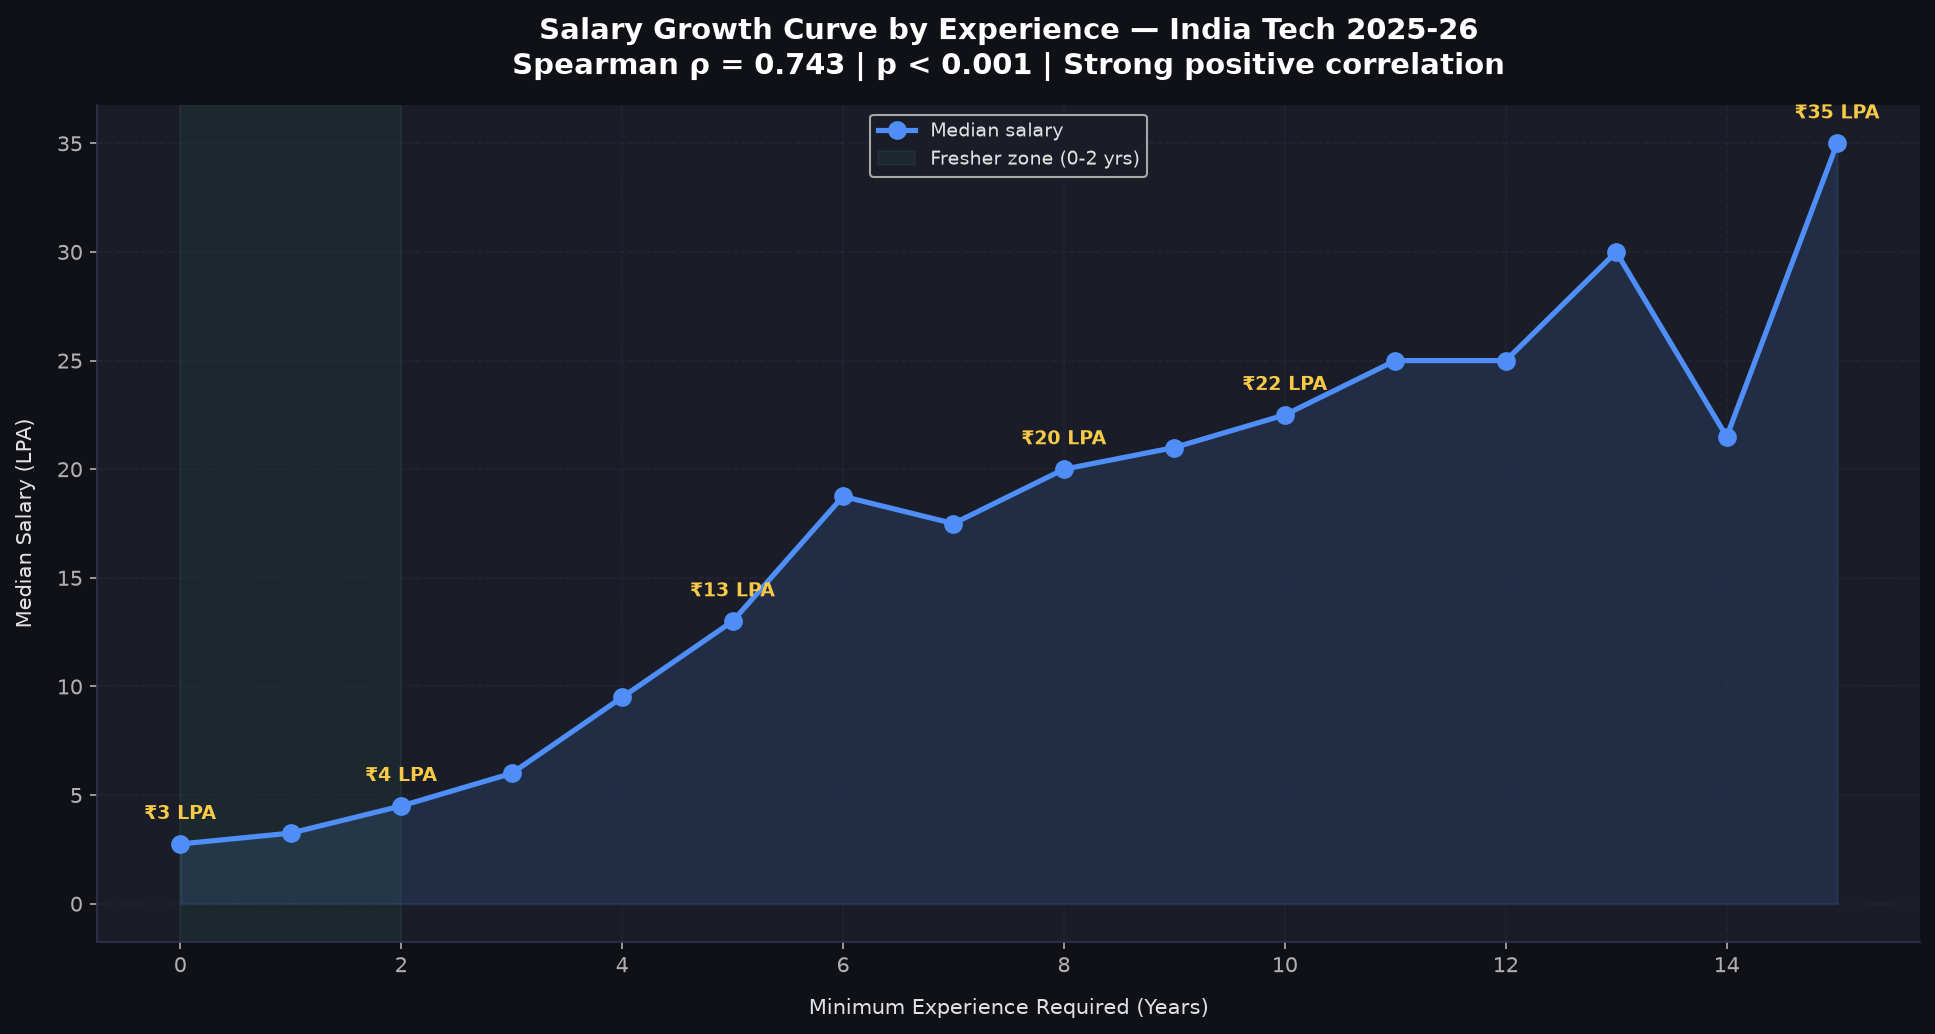

✅ Saved: ../outputs/charts/F3_experience_salary_regression.png


In [13]:
# ── Analysis 7.3: How does salary scale with experience? ─────

exp_salary = df_salary[['minimumExperience', 'salary_lpa']].copy()
exp_salary = exp_salary[exp_salary['minimumExperience'] <= 15]

# Spearman correlation (non-parametric, better for this data)
rho, p_spearman = stats.spearmanr(exp_salary['minimumExperience'],
                                   exp_salary['salary_lpa'])
print(f"Spearman Correlation (ρ): {rho:.4f}")
print(f"P-value:                  {p_spearman:.6f}")
print(f"Significant:              {p_spearman < 0.05}")

# Median salary by experience year
exp_grouped = (exp_salary.groupby('minimumExperience')['salary_lpa']
               .agg(['median', 'mean', 'count'])
               .reset_index()
               .rename(columns={'minimumExperience': 'exp_years'}))

print(f"\nMedian salary by experience year:")
print(exp_grouped[['exp_years', 'median', 'count']].to_string(index=False))

fig, ax = plt.subplots(figsize=(13, 7))

ax.plot(exp_grouped['exp_years'],
        exp_grouped['median'],
        color=COLORS['primary'],
        linewidth=2.5,
        marker='o',
        markersize=8,
        label='Median salary')

ax.fill_between(exp_grouped['exp_years'],
                exp_grouped['median'],
                alpha=0.15,
                color=COLORS['primary'])

# Annotate key points
for _, row in exp_grouped.iterrows():
    if row['exp_years'] in [0, 2, 5, 8, 10, 15]:
        ax.annotate(f"₹{row['median']:.0f} LPA",
                    xy=(row['exp_years'], row['median']),
                    xytext=(0, 12), textcoords='offset points',
                    ha='center', fontsize=9,
                    color=COLORS['secondary'],
                    fontweight='bold')

ax.axvspan(0, 2, alpha=0.08, color=COLORS['green'],
           label='Fresher zone (0-2 yrs)')

ax.set_xlabel('Minimum Experience Required (Years)', labelpad=10)
ax.set_ylabel('Median Salary (LPA)', labelpad=10)
ax.set_title(f'Salary Growth Curve by Experience — India Tech 2025-26\n'
             f'Spearman ρ = {rho:.3f} | p < 0.001 | Strong positive correlation',
             pad=15)
ax.legend(fontsize=9)
ax.grid(alpha=0.3)
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
save_chart('F3_experience_salary_regression.png')

Fresher rows with disclosed salary: 1,858
Overall fresher median salary: ₹3.50 LPA

Top 15 salary-premium skills for freshers:
                  skill  median_lpa  premium_pct  n
       Machine Learning      8.5000        142.9 27
     Automation Testing      7.8750        125.1 20
                   Java      6.0000         71.4 73
                   Data      5.5000         57.1 37
                 Python      5.5000         57.1 98
                    SQL      5.5000         57.1 73
Artificial Intelligence      5.4375         55.4 24
             Full Stack      5.2500         50.0 24
                    API      5.0000         42.9 28
                    AWS      5.0000         42.9 30
             JavaScript      4.7750         36.6 82
                  Linux      4.7500         35.7 26
                ReactJS      4.6250         32.0 58
                   .NET      4.5000         28.6 31
                Angular      4.5000         28.6 28


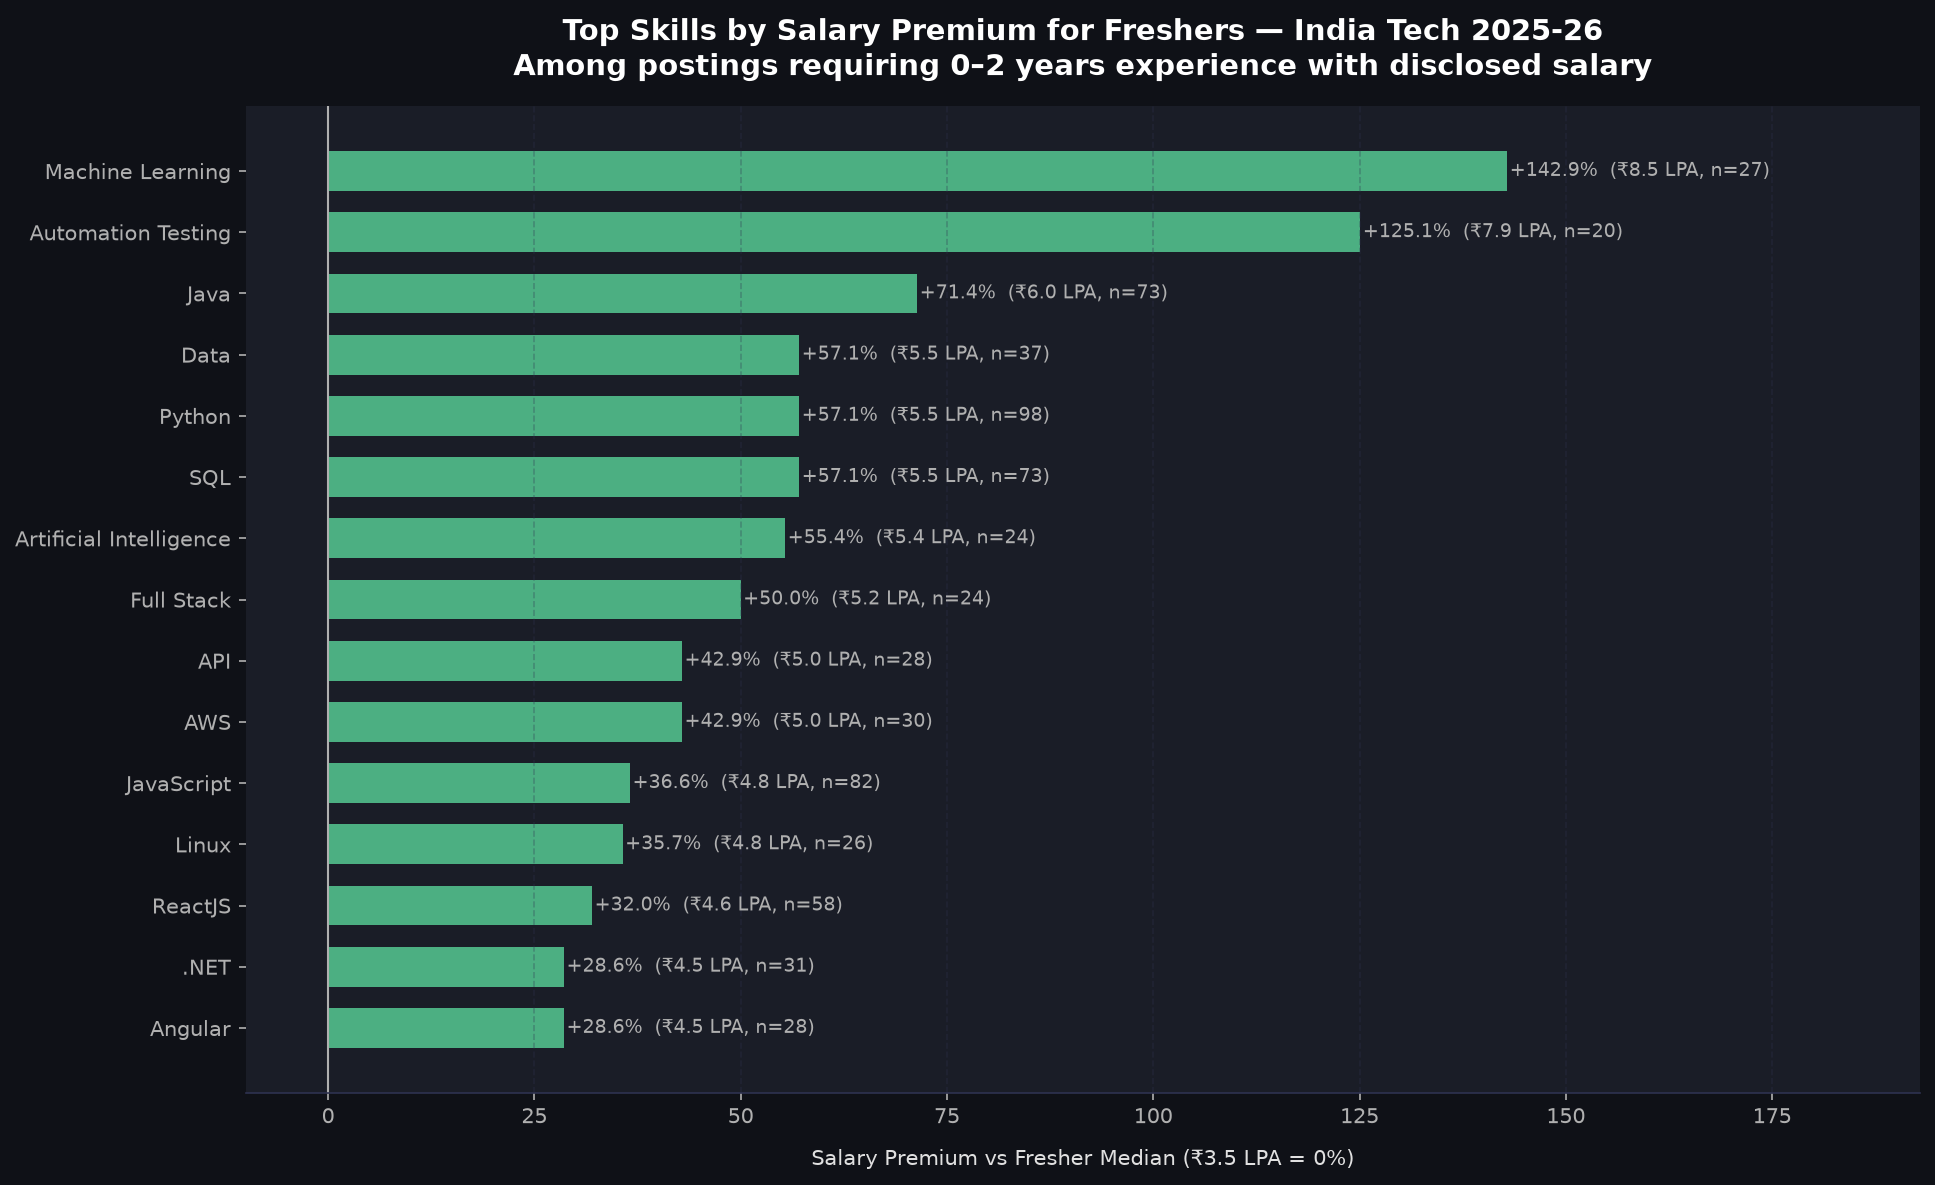

✅ Saved: ../outputs/charts/F4_fresher_skill_salary_premium.png


In [14]:
# ── Analysis 7.4: Which skills give freshers the best salary? ─

fresher_salary = df_salary[df_salary['minimumExperience'] <= 2].copy()
print(f"Fresher rows with disclosed salary: {len(fresher_salary):,}")

fresher_skill_salary = (df_skills[
    (df_skills['jobId'].isin(fresher_salary['jobId'])) &
    (df_skills['salary_lpa'] > 0)
].copy())

overall_fresher_median = fresher_salary['salary_lpa'].median()
print(f"Overall fresher median salary: ₹{overall_fresher_median:.2f} LPA")

skill_premium = (fresher_skill_salary.groupby('skill')['salary_lpa']
                 .agg(['median', 'count'])
                 .reset_index()
                 .rename(columns={'median': 'median_lpa', 'count': 'n'}))

skill_premium = skill_premium[skill_premium['n'] >= 20].copy()
skill_premium['premium_lpa'] = (skill_premium['median_lpa'] -
                                  overall_fresher_median).round(2)
skill_premium['premium_pct'] = (skill_premium['premium_lpa'] /
                                  overall_fresher_median * 100).round(1)

top_fresher_premium = skill_premium.nlargest(15, 'premium_pct')
print(f"\nTop 15 salary-premium skills for freshers:")
print(top_fresher_premium[['skill', 'median_lpa',
                             'premium_pct', 'n']].to_string(index=False))

fig, ax = plt.subplots(figsize=(13, 8))

colors_fp = [COLORS['green'] if p > 0 else COLORS['accent']
             for p in top_fresher_premium['premium_pct']]

bars = ax.barh(top_fresher_premium['skill'][::-1],
               top_fresher_premium['premium_pct'][::-1],
               color=colors_fp[::-1],
               edgecolor='none', height=0.65)

for bar, row in zip(bars, top_fresher_premium[::-1].itertuples()):
    ax.text(bar.get_width() + 0.3,
            bar.get_y() + bar.get_height()/2,
            f'+{row.premium_pct:.1f}%  (₹{row.median_lpa:.1f} LPA, n={row.n})',
            va='center', ha='left', fontsize=9, color=COLORS['subtext'])

ax.axvline(0, color=COLORS['subtext'], linewidth=1)
ax.set_xlabel(f'Salary Premium vs Fresher Median '
              f'(₹{overall_fresher_median:.1f} LPA = 0%)', labelpad=10)
ax.set_title('Top Skills by Salary Premium for Freshers — India Tech 2025-26\n'
             'Among postings requiring 0–2 years experience with disclosed salary',
             pad=15)
ax.set_xlim(-10, top_fresher_premium['premium_pct'].max() * 1.35)
ax.grid(axis='x', alpha=0.3)
ax.spines[['top', 'right', 'left']].set_visible(False)

plt.tight_layout()
save_chart('F4_fresher_skill_salary_premium.png')